<a href="https://colab.research.google.com/github/DHung154/BaiTapTuan4/blob/main/Autoencoder_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#BÀI TẬP: AUTOENCODER TRÊN CIFAR10

**Mục tiêu:** Xây dựng mô hình Autoencoder để nén và tái dựng ảnh từ bộ dữ liệu CIFAR10

---

## Kiến trúc Autoencoder

```
Input (32x32x3)  →  [ENCODER]  →  Latent Space (128)  →  [DECODER]  →  Output (32x32x3)
      ↓                                                                        ↓
   x = ảnh gốc                                                       o = ảnh tái dựng
                         o = D(E(x))
```

## Các nhãn CIFAR10
| Label | Mô tả       |
|-------|-------------|
| 0     | airplane    |
| 1     | automobile  |
| 2     | bird        |
| 3     | cat         |
| 4     | deer        |
| 5     | dog         |
| 6     | frog        |
| 7     | horse       |
| 8     | ship        |
| 9     | truck       |

---
## BƯỚC 1: Nạp thư viện

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.datasets import cifar10
import warnings
warnings.filterwarnings('ignore')

print('✅ Thư viện đã được nạp thành công!')
print(f'   Keras version: {keras.__version__}')

✅ Thư viện đã được nạp thành công!
   Keras version: 3.13.2


---
## BƯỚC 2: Nạp và tiền xử lý dữ liệu CIFAR10

In [2]:
# Tên nhãn CIFAR10
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Nạp dữ liệu
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print('📦 Thông tin dữ liệu gốc:')
print(f'   x_train shape: {x_train.shape}  → {x_train.shape[0]} ảnh, kích thước {x_train.shape[1]}x{x_train.shape[2]}x{x_train.shape[3]}')
print(f'   x_test  shape: {x_test.shape}')

# Chuẩn hóa pixel về [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# Flatten ảnh: 32x32x3 = 3072 chiều
input_dim = np.prod(x_train.shape[1:])  # 3072
x_train_flat = x_train.reshape(len(x_train), input_dim)
x_test_flat  = x_test.reshape(len(x_test), input_dim)

print(f'\n🔄 Sau khi flatten:')
print(f'   x_train_flat: {x_train_flat.shape}')
print(f'   x_test_flat:  {x_test_flat.shape}')
print(f'   input_dim = {input_dim} (32×32×3)')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
📦 Thông tin dữ liệu gốc:
   x_train shape: (50000, 32, 32, 3)  → 50000 ảnh, kích thước 32x32x3
   x_test  shape: (10000, 32, 32, 3)

🔄 Sau khi flatten:
   x_train_flat: (50000, 3072)
   x_test_flat:  (10000, 3072)
   input_dim = 3072 (32×32×3)


---
## BƯỚC 3: Hiển thị một số ảnh mẫu từ CIFAR10

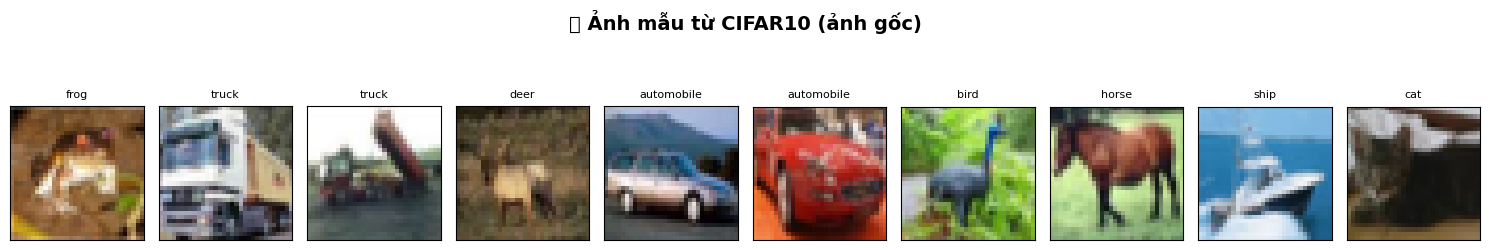

In [3]:
plt.figure(figsize=(15, 3))
plt.suptitle('📷 Ảnh mẫu từ CIFAR10 (ảnh gốc)', fontsize=14, fontweight='bold')

for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]], fontsize=8)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

---
## BƯỚC 4: Xây dựng mô hình Autoencoder

Kiến trúc:
- **Encoder:** Input(3072) → Dense(512, relu) → Dense(256, relu) → Dense(128, relu)
- **Decoder:** Dense(256, relu) → Dense(512, relu) → Dense(3072, sigmoid)

In [6]:
# Kích thước không gian ẩn (latent space)
encoding_dim = 128  # nén từ 3072 → 128 (hệ số nén ~24x)

# ============================================================
# XÂY DỰNG ENCODER
# ============================================================
input_img = keras.Input(shape=(int(input_dim),), name='encoder_input')

# Encoder layers: giảm dần kích thước
x = layers.Dense(512, activation='relu', name='enc_dense_1')(input_img)
x = layers.Dense(256, activation='relu', name='enc_dense_2')(x)
encoded = layers.Dense(encoding_dim, activation='relu', name='latent_space')(x)

# ============================================================
# XÂY DỰNG DECODER
# ============================================================
# Decoder layers: tăng dần kích thước (đối xứng với encoder)
y = layers.Dense(256, activation='relu', name='dec_dense_1')(encoded)
y = layers.Dense(512, activation='relu', name='dec_dense_2')(y)
decoded = layers.Dense(int(input_dim), activation='sigmoid', name='decoder_output')(y)

# ============================================================
# TẠO CÁC MODEL
# ============================================================
# Full autoencoder: input → encoder → decoder → output
autoencoder = keras.Model(input_img, decoded, name='autoencoder')

# Chỉ encoder: input → latent space
encoder = keras.Model(input_img, encoded, name='encoder')

# Chỉ decoder: latent space → reconstructed output
encoded_input = keras.Input(shape=(encoding_dim,), name='decoder_input')
dec_layer1 = autoencoder.get_layer('dec_dense_1')
dec_layer2 = autoencoder.get_layer('dec_dense_2')
dec_output = autoencoder.get_layer('decoder_output')
decoder = keras.Model(encoded_input,
                      dec_output(dec_layer2(dec_layer1(encoded_input))),
                      name='decoder')

print('✅ Mô hình đã được xây dựng!')
print(f'   Input dim:    {input_dim}')
print(f'   Encoding dim: {encoding_dim}')
print(f'   Hệ số nén:    {input_dim/encoding_dim:.1f}x')

✅ Mô hình đã được xây dựng!
   Input dim:    3072
   Encoding dim: 128
   Hệ số nén:    24.0x


In [7]:
# Xem kiến trúc toàn bộ Autoencoder
print('=' * 60)
print('              KIẾN TRÚC AUTOENCODER')
print('=' * 60)
autoencoder.summary()

              KIẾN TRÚC AUTOENCODER


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_1 (Dense)             │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_dense_2 (Dense)             │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_1 (Dense)             │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense_2 (Dense)             │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 3072)           │     1,575,936 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,478,144 (13.27 MB)

 Trainable params: 3,478,144 (13.27 MB)

 Non-trainable params: 0 (0.00 B)

---
## BƯỚC 5: Biên dịch và huấn luyện mô hình

In [8]:
# Biên dịch mô hình
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('🚀 Bắt đầu huấn luyện...')
print('   Optimizer: Adam')
print('   Loss:      Binary Crossentropy')
print('   Epochs:    50')
print('   Batch:     256')
print()

# Huấn luyện
# Lưu ý: x_train được dùng làm CẢ INPUT lẫn TARGET (tái dựng chính nó)
history = autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=50,
    batch_size=256,
    shuffle=True,
    verbose=1,
    validation_data=(x_test_flat, x_test_flat)
)

print('\n✅ Huấn luyện hoàn tất!')

🚀 Bắt đầu huấn luyện...
   Optimizer: Adam
   Loss:      Binary Crossentropy
   Epochs:    50
   Batch:     256

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - accuracy: 0.0021 - loss: 0.6344 - val_accuracy: 0.0028 - val_loss: 0.6061
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.0037 - loss: 0.6007 - val_accuracy: 0.0036 - val_loss: 0.5973
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.0042 - loss: 0.5944 - val_accuracy: 0.0059 - val_loss: 0.5935
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 0.0052 - loss: 0.5903 - val_accuracy: 0.0061 - val_loss: 0.5899
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - accuracy: 0.0058 - loss: 0.5880 - val_accuracy: 0.0083 - val_loss: 0.5872
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - accuracy: 0.0059 - loss: 0.5857 - val_accuracy: 0.0084 - val_loss: 0.5882
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - accuracy: 0.0067 - loss: 0.5839 - val_accuracy: 0.

---
## BƯỚC 6: Vẽ đồ thị đánh giá quá trình huấn luyện

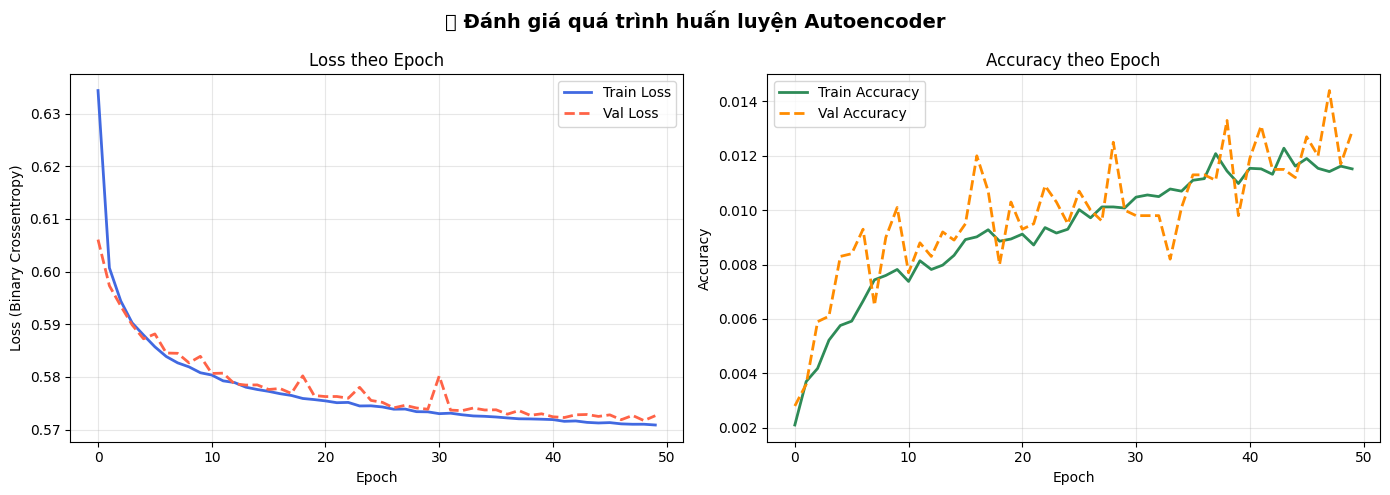

📈 Kết quả cuối cùng:
   Train Loss : 0.5709
   Val   Loss : 0.5726


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 Đánh giá quá trình huấn luyện Autoencoder', fontsize=14, fontweight='bold')

# --- Đồ thị Loss ---
axes[0].plot(history.history['loss'],     label='Train Loss', color='royalblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('Loss theo Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Binary Crossentropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Đồ thị Accuracy ---
axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='seagreen',  linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title('Accuracy theo Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# In kết quả cuối
final_loss     = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
print(f'📈 Kết quả cuối cùng:')
print(f'   Train Loss : {final_loss:.4f}')
print(f'   Val   Loss : {final_val_loss:.4f}')

---
## BƯỚC 7: Dự báo (encode + decode ảnh test)

In [10]:
# Encode: nén ảnh test xuống không gian ẩn
encoded_imgs = encoder.predict(x_test_flat, verbose=0)

# Decode: tái dựng lại ảnh từ không gian ẩn
decoded_imgs = decoder.predict(encoded_imgs, verbose=0)

print(f'✅ Encode & Decode hoàn tất!')
print(f'   Ảnh gốc (flat):    {x_test_flat.shape}')
print(f'   Encoded (nén):     {encoded_imgs.shape}  ← không gian ẩn')
print(f'   Decoded (tái dựng):{decoded_imgs.shape}')

✅ Encode & Decode hoàn tất!
   Ảnh gốc (flat):    (10000, 3072)
   Encoded (nén):     (10000, 128)  ← không gian ẩn
   Decoded (tái dựng):(10000, 3072)


---
## BƯỚC 8: Hiển thị ảnh gốc vs ảnh tái dựng

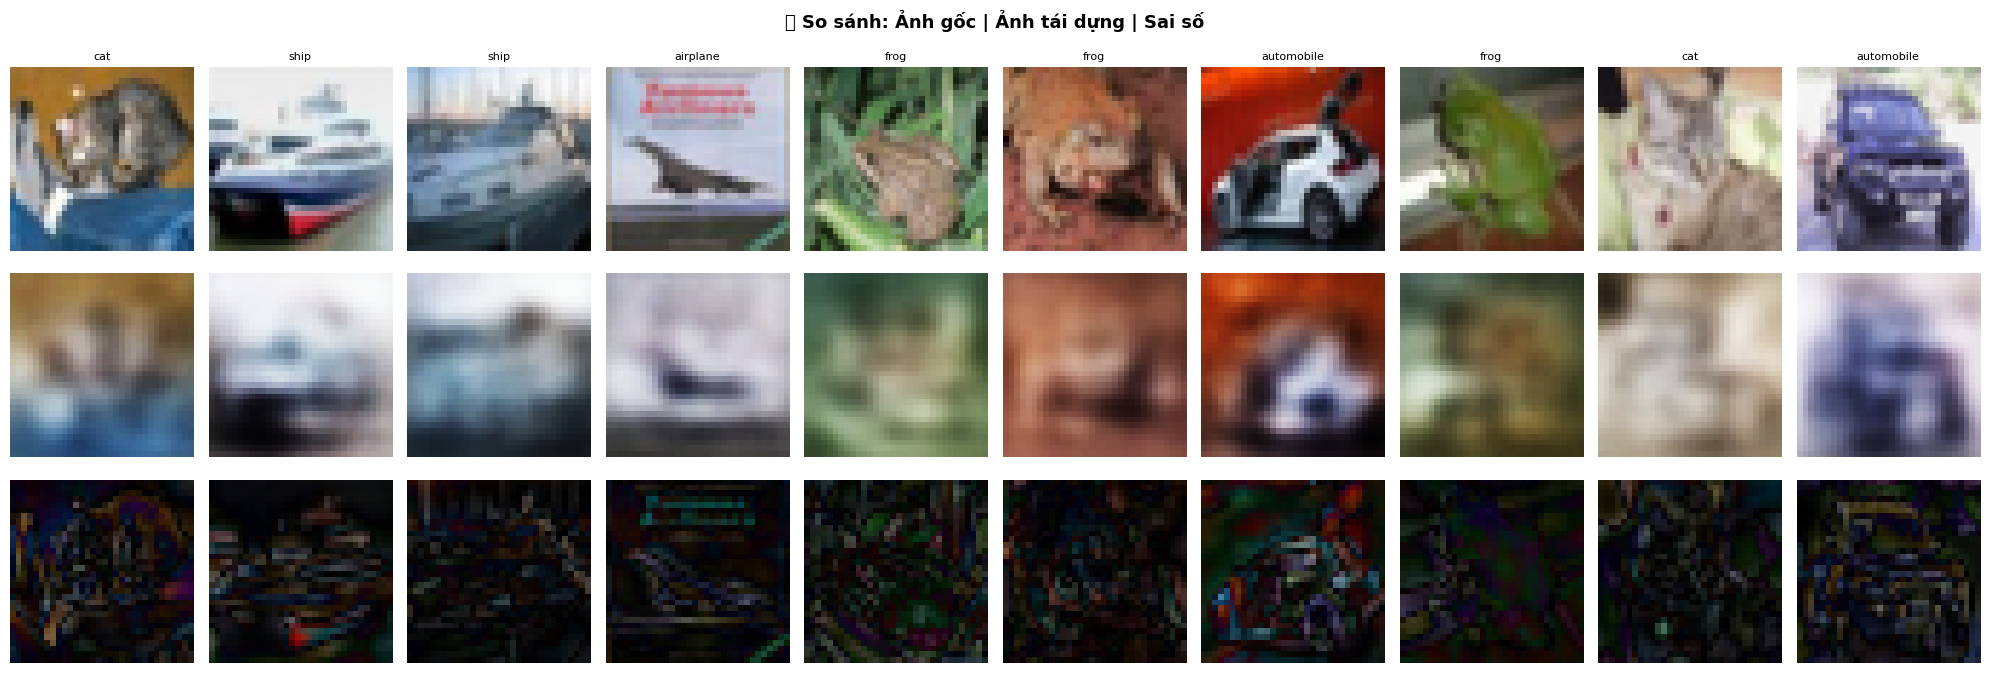

In [11]:
n = 10  # Số ảnh hiển thị

fig, axes = plt.subplots(3, n, figsize=(20, 7))
fig.suptitle('🖼️ So sánh: Ảnh gốc | Ảnh tái dựng | Sai số', fontsize=13, fontweight='bold')

for i in range(n):
    # Reshape về 32x32x3
    original    = x_test_flat[i].reshape(32, 32, 3)
    reconstructed = decoded_imgs[i].reshape(32, 32, 3)
    diff        = np.abs(original - reconstructed)

    # Hàng 1: Ảnh gốc
    axes[0, i].imshow(original)
    axes[0, i].set_title(class_names[y_test[i][0]], fontsize=8)
    axes[0, i].axis('off')

    # Hàng 2: Ảnh tái dựng
    axes[1, i].imshow(np.clip(reconstructed, 0, 1))
    axes[1, i].axis('off')

    # Hàng 3: Sai số (difference map)
    axes[2, i].imshow(diff, cmap='hot')
    axes[2, i].axis('off')

# Nhãn hàng
axes[0, 0].set_ylabel('Gốc', fontsize=10, rotation=0, labelpad=40)
axes[1, 0].set_ylabel('Tái dựng', fontsize=10, rotation=0, labelpad=40)
axes[2, 0].set_ylabel('Sai số', fontsize=10, rotation=0, labelpad=40)

plt.tight_layout()
plt.show()

---
## BƯỚC 9: Đánh giá chất lượng tái dựng (MSE & PSNR)

In [12]:
# Tính MSE trung bình trên toàn bộ tập test
mse_per_image = np.mean((x_test_flat - decoded_imgs) ** 2, axis=1)
avg_mse = np.mean(mse_per_image)

# PSNR (Peak Signal-to-Noise Ratio) - càng cao càng tốt
# PSNR = 20 * log10(MAX) - 10 * log10(MSE)
# MAX = 1.0 vì ảnh đã chuẩn hóa
psnr_per_image = 20 * np.log10(1.0) - 10 * np.log10(mse_per_image + 1e-10)
avg_psnr = np.mean(psnr_per_image)

print('=' * 50)
print('      📊 ĐÁNH GIÁ CHẤT LƯỢNG TÁI DỰNG')
print('=' * 50)
print(f'  MSE trung bình  : {avg_mse:.6f}')
print(f'  PSNR trung bình : {avg_psnr:.2f} dB')
print('=' * 50)
print(f'  → PSNR > 30 dB: chất lượng tốt')
print(f'  → PSNR > 20 dB: chấp nhận được')
print(f'  → PSNR < 20 dB: chất lượng thấp')

# MSE theo từng nhãn
print('\n  MSE theo từng nhãn:')
for label in range(10):
    mask = y_test.flatten() == label
    class_mse = np.mean(mse_per_image[mask])
    print(f'    [{label}] {class_names[label]:<12}: MSE = {class_mse:.6f}')

      📊 ĐÁNH GIÁ CHẤT LƯỢNG TÁI DỰNG
  MSE trung bình  : 0.009713
  PSNR trung bình : 20.64 dB
  → PSNR > 30 dB: chất lượng tốt
  → PSNR > 20 dB: chấp nhận được
  → PSNR < 20 dB: chất lượng thấp

  MSE theo từng nhãn:
    [0] airplane    : MSE = 0.008478
    [1] automobile  : MSE = 0.012952
    [2] bird        : MSE = 0.008042
    [3] cat         : MSE = 0.009594
    [4] deer        : MSE = 0.007225
    [5] dog         : MSE = 0.009818
    [6] frog        : MSE = 0.009272
    [7] horse       : MSE = 0.011097
    [8] ship        : MSE = 0.007963
    [9] truck       : MSE = 0.012691


---
## BƯỚC 10: Thực nghiệm với số Epochs khác nhau (50, 100, 200)

> **Yêu cầu bài:** Huấn luyện lại với epochs: 50, 100, 200 để xem sự khác biệt

In [14]:
def build_autoencoder(input_dim, encoding_dim=128):
    """Hàm tạo autoencoder mới"""
    inp = keras.Input(shape=(int(input_dim),))
    x   = layers.Dense(512, activation='relu')(inp)
    x   = layers.Dense(256, activation='relu')(x)
    enc = layers.Dense(encoding_dim, activation='relu')(x)
    y   = layers.Dense(256, activation='relu')(enc)
    y   = layers.Dense(512, activation='relu')(y)
    dec = layers.Dense(int(input_dim), activation='sigmoid')(y)
    model = keras.Model(inp, dec)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

results = {}
epoch_list = [50, 100, 200]

for ep in epoch_list:
    print(f'\n🔄 Đang huấn luyện {ep} epochs...')
    m = build_autoencoder(input_dim)
    h = m.fit(
        x_train_flat, x_train_flat,
        epochs=ep, batch_size=256,
        shuffle=True, verbose=0,
        validation_data=(x_test_flat, x_test_flat)
    )
    preds = m.predict(x_test_flat, verbose=0)
    mse   = np.mean((x_test_flat - preds) ** 2)
    results[ep] = {'history': h, 'preds': preds, 'mse': mse}
    print(f'   ✅ Done! Final val_loss={h.history["val_loss"][-1]:.4f}, MSE={mse:.6f}')

print('\n✅ Hoàn tất thực nghiệm!')


🔄 Đang huấn luyện 50 epochs...
   ✅ Done! Final val_loss=0.5718, MSE=0.009319

🔄 Đang huấn luyện 100 epochs...
   ✅ Done! Final val_loss=0.5692, MSE=0.008345

🔄 Đang huấn luyện 200 epochs...
   ✅ Done! Final val_loss=0.5676, MSE=0.007723

✅ Hoàn tất thực nghiệm!


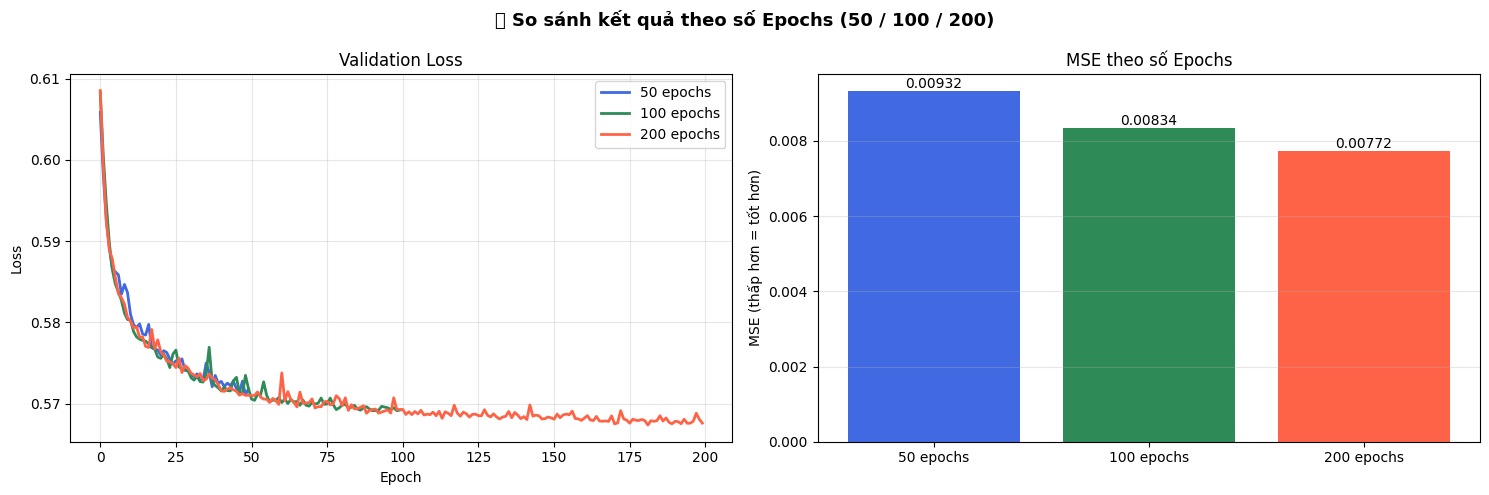

In [15]:
# So sánh loss của 3 kịch bản
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('📊 So sánh kết quả theo số Epochs (50 / 100 / 200)', fontsize=13, fontweight='bold')

colors = ['royalblue', 'seagreen', 'tomato']
for i, ep in enumerate(epoch_list):
    axes[0].plot(results[ep]['history'].history['val_loss'],
                 label=f'{ep} epochs', color=colors[i], linewidth=2)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart MSE
mse_vals = [results[ep]['mse'] for ep in epoch_list]
bars = axes[1].bar([str(e)+' epochs' for e in epoch_list], mse_vals, color=colors)
axes[1].set_title('MSE theo số Epochs')
axes[1].set_ylabel('MSE (thấp hơn = tốt hơn)')
for bar, v in zip(bars, mse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00001,
                 f'{v:.5f}', ha='center', va='bottom', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

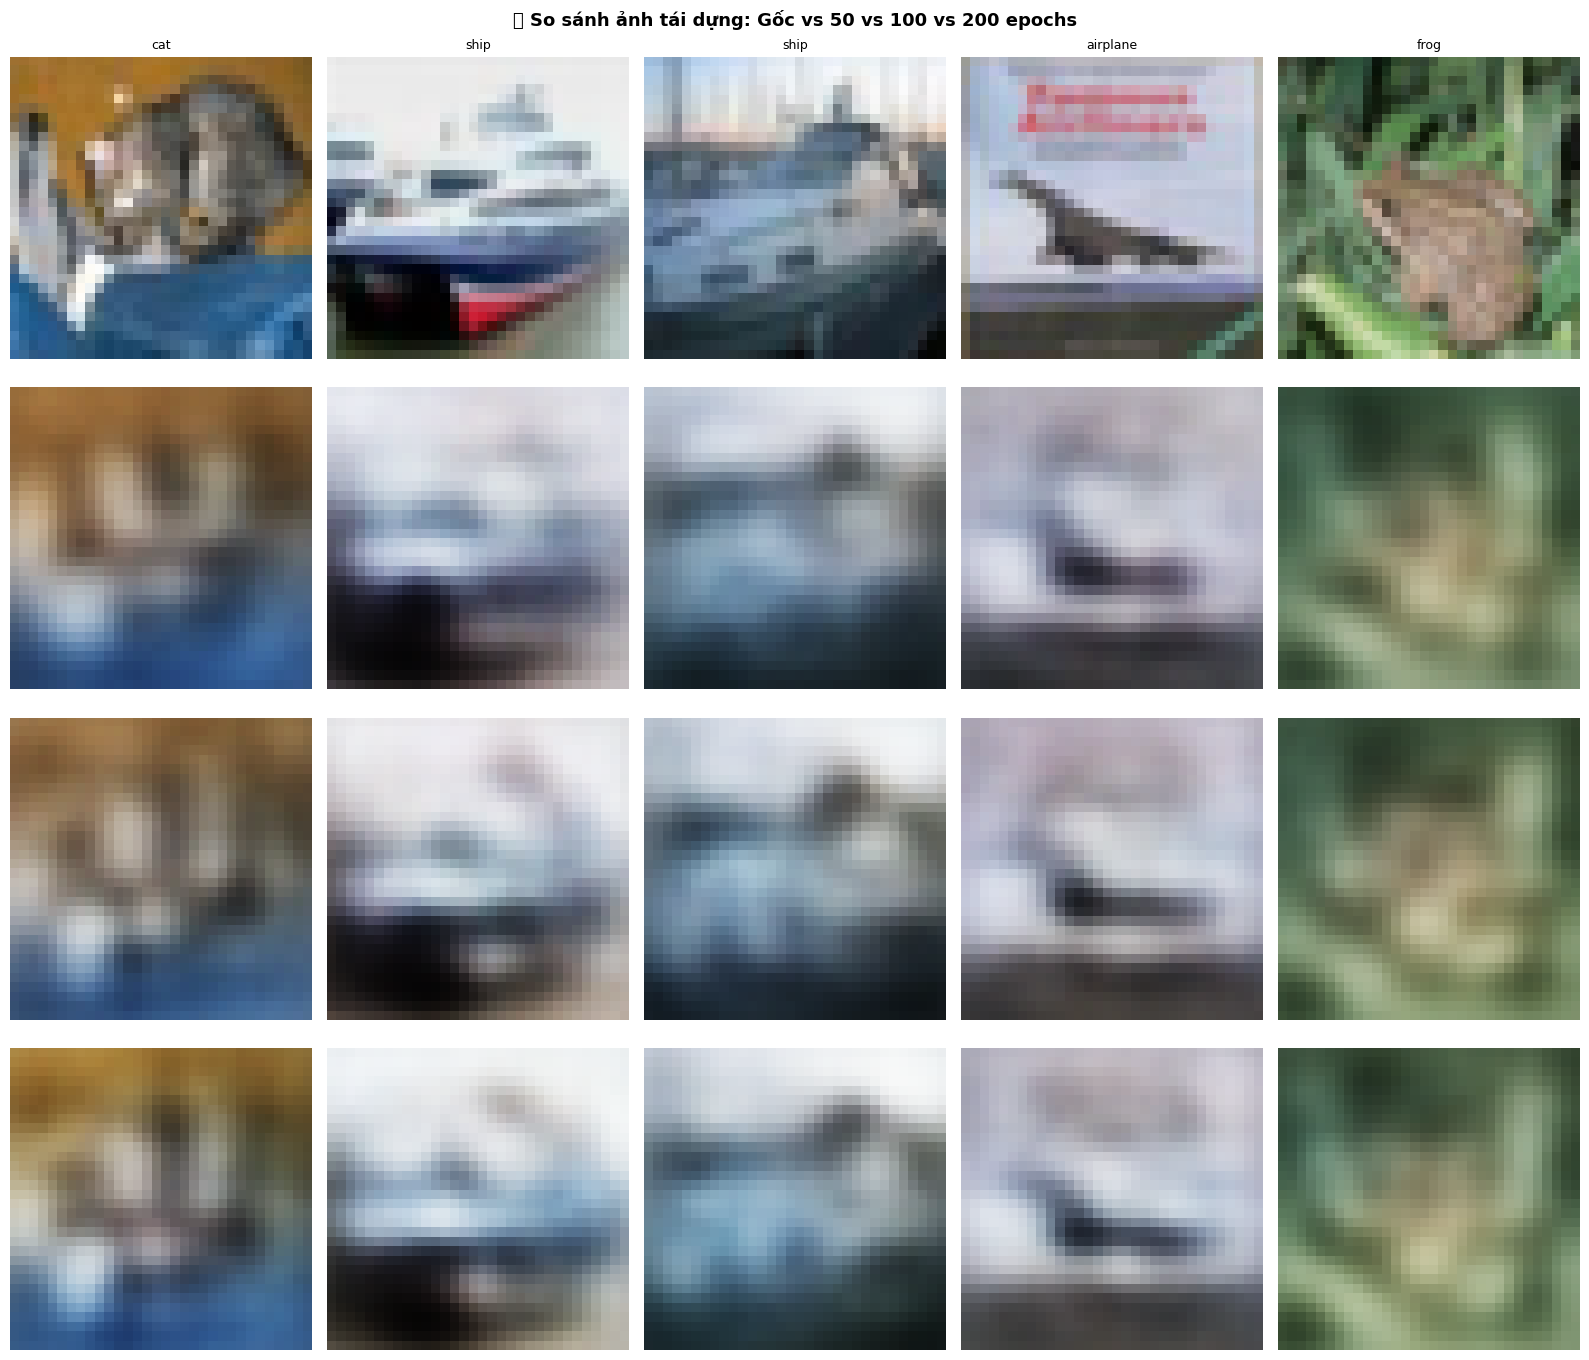


📌 Nhận xét:
   50 epochs → MSE = 0.009319
   100 epochs → MSE = 0.008345
   200 epochs → MSE = 0.007723
   → Số epochs càng nhiều, ảnh tái dựng càng rõ nét hơn


In [16]:
# So sánh ảnh tái dựng của 3 kịch bản
n_show = 5
fig, axes = plt.subplots(4, n_show, figsize=(16, 14))
fig.suptitle('🖼️ So sánh ảnh tái dựng: Gốc vs 50 vs 100 vs 200 epochs', fontsize=13, fontweight='bold')

row_labels = ['Ảnh gốc', '50 epochs', '100 epochs', '200 epochs']
preds_list = [x_test_flat] + [results[ep]['preds'] for ep in epoch_list]

for row, (label, preds) in enumerate(zip(row_labels, preds_list)):
    for col in range(n_show):
        img = preds[col].reshape(32, 32, 3)
        axes[row, col].imshow(np.clip(img, 0, 1))
        if col == 0:
            axes[row, col].set_ylabel(label, fontsize=10, rotation=0, labelpad=70, va='center')
        if row == 0:
            axes[row, col].set_title(class_names[y_test[col][0]], fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print('\n📌 Nhận xét:')
for ep, mse in zip(epoch_list, mse_vals):
    print(f'   {ep} epochs → MSE = {mse:.6f}')
print('   → Số epochs càng nhiều, ảnh tái dựng càng rõ nét hơn')

---
## BƯỚC 11: Cải tiến với L1 Regularization

In [18]:
from keras import regularizers

# Xây dựng autoencoder với L1 regularization
input_img_l1 = keras.Input(shape=(int(input_dim),))
encoded_l1   = layers.Dense(512, activation='relu')(input_img_l1)
encoded_l1   = layers.Dense(256, activation='relu')(encoded_l1)
encoded_l1   = layers.Dense(
    encoding_dim,
    activation='relu',
    activity_regularizer=regularizers.l1(1e-5)  # thêm L1
)(encoded_l1)
decoded_l1   = layers.Dense(256, activation='relu')(encoded_l1)
decoded_l1   = layers.Dense(512, activation='relu')(decoded_l1)
decoded_l1   = layers.Dense(int(input_dim), activation='sigmoid')(decoded_l1)

ae_l1 = keras.Model(input_img_l1, decoded_l1)
ae_l1.compile(optimizer='adam', loss='binary_crossentropy')

print('🚀 Huấn luyện Autoencoder + L1 (50 epochs)...')
history_l1 = ae_l1.fit(
    x_train_flat, x_train_flat,
    epochs=50, batch_size=256, shuffle=True, verbose=1,
    validation_data=(x_test_flat, x_test_flat)
)

decoded_l1_imgs = ae_l1.predict(x_test_flat, verbose=0)
mse_l1 = np.mean((x_test_flat - decoded_l1_imgs) ** 2)
print(f'\n✅ Xong! MSE với L1 = {mse_l1:.6f}')
print(f'   MSE không có L1 = {results[50]["mse"]:.6f}')

🚀 Huấn luyện Autoencoder + L1 (50 epochs)...
Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - loss: 0.6905 - val_loss: 0.6894
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - loss: 0.6892 - val_loss: 0.6894
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 99ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 9/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 10/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - loss: 0.6891 - val_loss: 0.6894
Epoch 11/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - loss: 0.6891 - v

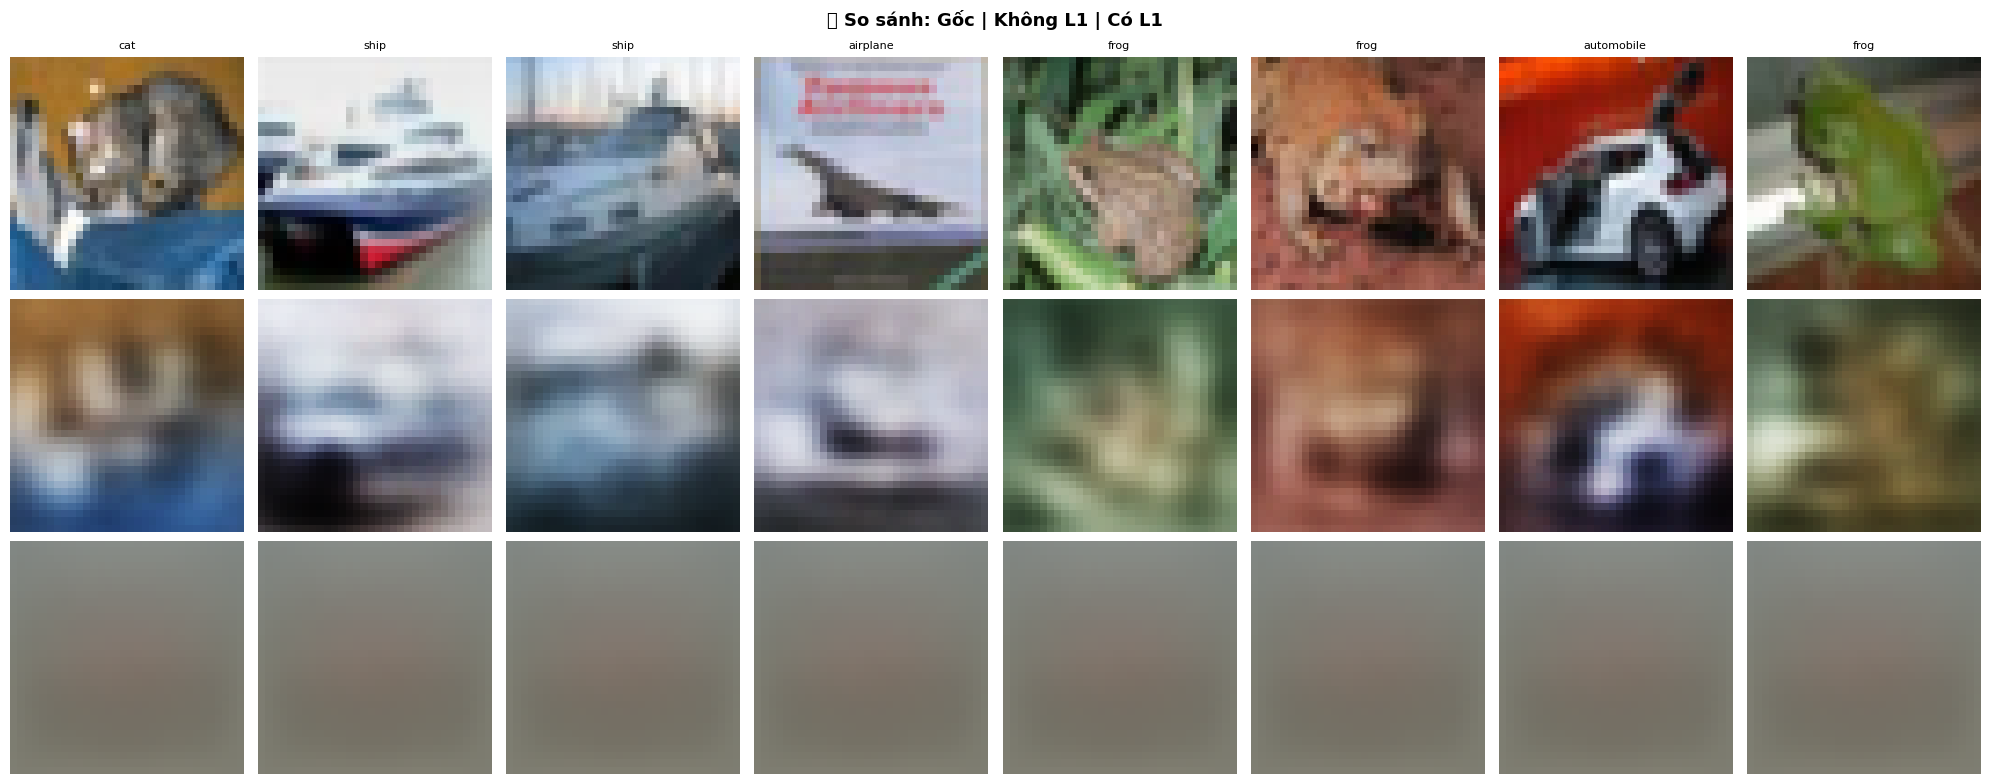

In [19]:
# So sánh ảnh: không có L1 vs có L1
n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(20, 8))
fig.suptitle('🔬 So sánh: Gốc | Không L1 | Có L1', fontsize=13, fontweight='bold')

for i in range(n_show):
    # Ảnh gốc
    axes[0, i].imshow(x_test[i])
    axes[0, i].set_title(class_names[y_test[i][0]], fontsize=8)
    axes[0, i].axis('off')

    # Không L1
    axes[1, i].imshow(np.clip(results[50]['preds'][i].reshape(32,32,3), 0, 1))
    axes[1, i].axis('off')

    # Có L1
    axes[2, i].imshow(np.clip(decoded_l1_imgs[i].reshape(32,32,3), 0, 1))
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Gốc',      fontsize=10, rotation=0, labelpad=40, va='center')
axes[1, 0].set_ylabel('Không L1', fontsize=10, rotation=0, labelpad=40, va='center')
axes[2, 0].set_ylabel('Có L1',    fontsize=10, rotation=0, labelpad=40, va='center')

plt.tight_layout()
plt.show()

---
## BƯỚC 12: Tổng kết và đánh giá

### 📌 Bảng tổng hợp kết quả

In [20]:
print('=' * 65)
print('         📊 BẢNG TỔNG HỢP KẾT QUẢ AUTOENCODER CIFAR10')
print('=' * 65)
print(f"{'Mô hình':<30} {'Epochs':>8} {'MSE':>12} {'Val Loss':>12}")
print('-' * 65)

for ep in epoch_list:
    vl = results[ep]['history'].history['val_loss'][-1]
    print(f"{'AE cơ bản':<30} {ep:>8} {results[ep]['mse']:>12.6f} {vl:>12.4f}")

vl_l1 = history_l1.history['val_loss'][-1]
print(f"{'AE + L1 (1e-5)':<30} {'50':>8} {mse_l1:>12.6f} {vl_l1:>12.4f}")
print('=' * 65)

print("""
📝 Nhận xét:
  1. Số Epochs càng tăng → MSE càng giảm → ảnh tái dựng càng rõ nét
  2. L1 Regularization giúp mô hình học biểu diễn thưa (sparse)
     → không gian ẩn gọn hơn, tránh overfitting
  3. CIFAR10 (màu, 32x32) khó hơn MNIST (xám, 28x28)
     → cần nhiều epochs & kiến trúc sâu hơn để đạt chất lượng tốt
  4. Encoder nén 3072 → 128 chiều (hệ số 24x) vẫn giữ được
     đặc trưng cơ bản của từng lớp ảnh
""")

         📊 BẢNG TỔNG HỢP KẾT QUẢ AUTOENCODER CIFAR10
Mô hình                          Epochs          MSE     Val Loss
-----------------------------------------------------------------
AE cơ bản                            50     0.009319       0.5718
AE cơ bản                           100     0.008345       0.5692
AE cơ bản                           200     0.007723       0.5676
AE + L1 (1e-5)                       50     0.061790       0.6894

📝 Nhận xét:
  1. Số Epochs càng tăng → MSE càng giảm → ảnh tái dựng càng rõ nét
  2. L1 Regularization giúp mô hình học biểu diễn thưa (sparse)
     → không gian ẩn gọn hơn, tránh overfitting
  3. CIFAR10 (màu, 32x32) khó hơn MNIST (xám, 28x28)
     → cần nhiều epochs & kiến trúc sâu hơn để đạt chất lượng tốt
  4. Encoder nén 3072 → 128 chiều (hệ số 24x) vẫn giữ được
     đặc trưng cơ bản của từng lớp ảnh

